In [1]:
from IPython.display import HTML, display
import time

def progress(value, max=100, label=''):
    return HTML("""
        <div style='display:flex;gap:10px;width:50%'>
            <div>{label}</div>
            <progress
                value='{value}'
                max='{max}',
                style='flex: 1'
            >
                {value}
            </progress>
        </div>
    """.format(label=label, value=value, max=max))

#out = display(progress(0, 100, 'Test'), display_id=True)
#for ii in range(101):
#    time.sleep(0.02)
#    out.update(progress(ii, 100, 'Test'))

In [3]:
import kagglehub
import numpy as np
import cv2
import os

# Download dataset
path = kagglehub.dataset_download("l3llff/flowers")
print("Path to dataset files:", path)
image_folder = f"{path}/flowers"

# Separate images and labels
skip, skip_except = (False, ["rose", "iris", "dandelion"])
images = []
labels = []
for class_name in os.listdir(image_folder):
    class_path = os.path.join(image_folder, class_name)
    if skip and class_name not in skip_except:
        continue
    size = len(os.listdir(class_path))
    bar = display(progress(0, 100, label=f"Loading {class_name} ({size})"), display_id=True)
    count = 0
    if os.path.isdir(class_path):
        for image_name in os.listdir(class_path):
            image_path = os.path.join(class_path, image_name)
            img = cv2.imread(image_path)
            images.append(img)
            labels.append(class_name)
            count += 1
            bar.update(progress(count / size * 100, label=f"Loading {class_name} ({size})"))
print("Dataset fully loaded")

c:\Users\alexandreguimaraes\Desktop\Nova pasta\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 228M/228M [00:27<00:00, 8.54MB/s] 

Extracting files...


Path to dataset files: C:\Users\alexandreguimaraes\.cache\kagglehub\datasets\l3llff\flowers\versions\4


Dataset fully loaded


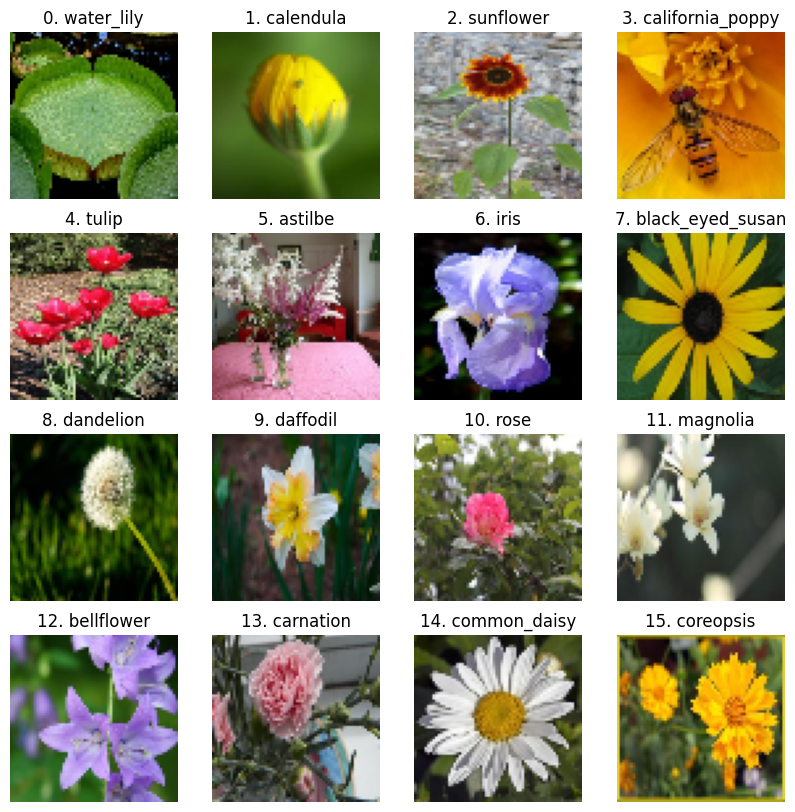

In [4]:
import matplotlib.pyplot as plt

# Define useful globals
image_size = 64
image_dimensions = (image_size, image_size)
image_shape = (image_size, image_size, 3)
map_label_name_to_num = dict([(name,num) for num,name in enumerate(set(labels))])
map_label_num_to_name = dict([(num,name) for num,name in enumerate(set(labels))])

# Build X and y, making sure to flatten the images
X = []
y = [map_label_name_to_num[name] for name in labels]
for img in images:
    img = cv2.resize(img, image_dimensions)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = np.array(img)
    img = img.flatten()
    X.append(img)

# Transform both to numpy array, then normalize X
X = np.array(X)
y = np.array(y)
X = X / 255.0

# Show an example for each class
_, axes = plt.subplots(4, 4, figsize=(10, 10))
for i in range(len(np.unique(y))):
    row = i // 4
    col = i % 4
    images_in_class = X[y == i]
    random_index = np.random.choice(len(images_in_class))
    image_sample = images_in_class[random_index].reshape(image_shape)
    axes[row, col].set_title(f"{i}. {map_label_num_to_name[i]}")
    axes[row, col].imshow(image_sample)
    axes[row, col].axis('off')
plt.show()

In [5]:
# Let's understand the dataset better
# We try to apply dimensionality reduction on a subset of three classes
is_iris_rose_dandelion = np.isin(y, [map_label_name_to_num[n] for n in ["iris", "rose", "dandelion"]])
X_irises_roses_dandelions = X[is_iris_rose_dandelion]
y_irises_roses_dandelions = y[is_iris_rose_dandelion]
print(f"Xy_irises_roses_dandelions size: {len(X_irises_roses_dandelions)}, {len(X_irises_roses_dandelions)}")

Xy_irises_roses_dandelions size: 3105, 3105


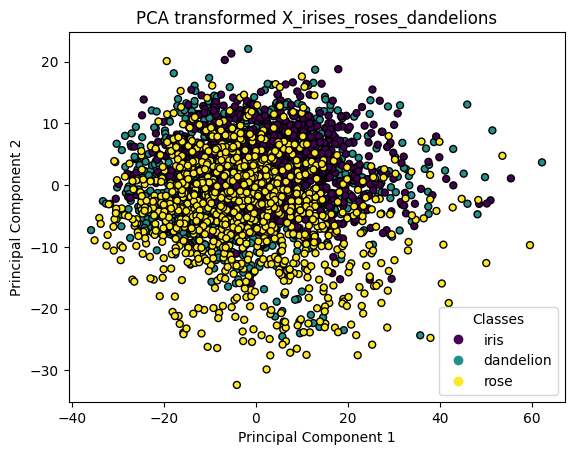

In [6]:
from sklearn.decomposition import PCA

# Apply Principal Component Analysis
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_irises_roses_dandelions)
y_pca = y_irises_roses_dandelions

# Plot results
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], marker="o", s=25, c=y_pca, edgecolor="k")
handles = [plt.Line2D([], [], marker="o", color=scatter.cmap(scatter.norm(c)), linestyle="", label=l) for l,c in map_label_name_to_num.items() if l in ["iris", "rose", "dandelion"]]
plt.legend(handles=handles, title="Classes")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA transformed X_irises_roses_dandelions")
plt.show()

c:\Users\alexandreguimaraes\Desktop\Nova pasta\venv\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] O sistema não pode encontrar o arquivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\alexandreguimaraes\Desktop\Nova pasta\venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\alexandreguimaraes\Miniconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\alexandreguimaraes\Miniconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\alexandreguim

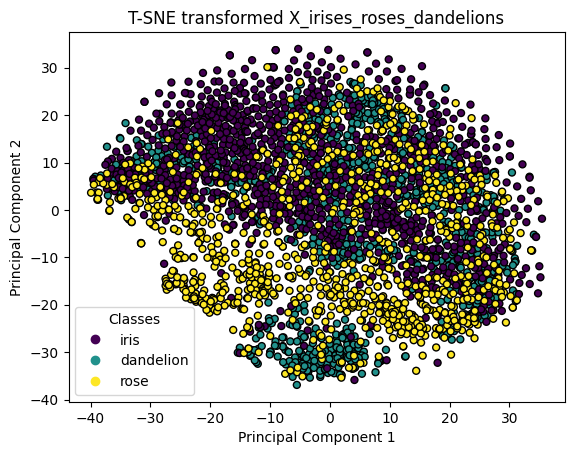

In [7]:
from sklearn.manifold import TSNE

# Apply T-distributed Stochastic Neighbor Embedding
sne = TSNE(n_components=2, learning_rate=500, perplexity=30)
X_sne = sne.fit_transform(X_irises_roses_dandelions)
y_sne = y_irises_roses_dandelions

# Plot results
scatter = plt.scatter(X_sne[:, 0], X_sne[:, 1], marker="o", s=25, c=y_sne, edgecolor="k")
handles = [plt.Line2D([], [], marker="o", color=scatter.cmap(scatter.norm(c)), linestyle="", label=l) for l,c in map_label_name_to_num.items() if l in ["iris", "rose", "dandelion"]]
plt.legend(handles=handles, title="Classes")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("T-SNE transformed X_irises_roses_dandelions")
plt.show()

Train size: 11018. Test size: 3148


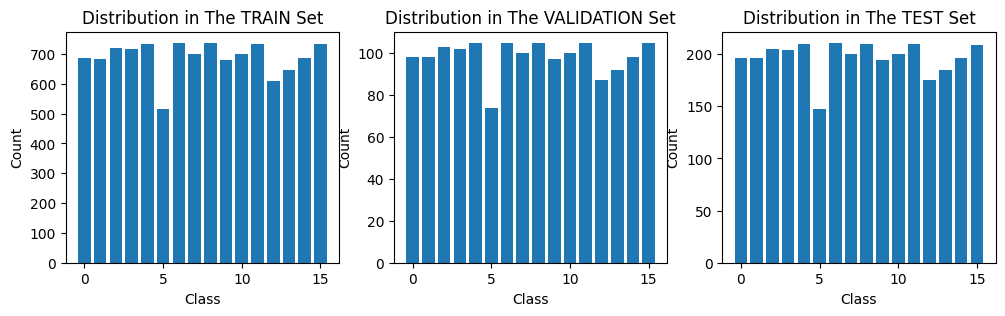

In [8]:
from sklearn.model_selection import train_test_split

# Generate train (70%), validation (10%) and test (20%) sets for X and y
_X_tmp, X_test, _y_tmp, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(_X_tmp, _y_tmp, test_size=0.125, shuffle=True, stratify=_y_tmp, random_state=42)
print(f"Train size: {len(X_train)}. Test size: {len(X_test)}")

# Get unique classes and their counts to plot distribution
y_train_classes, y_train_counts = np.unique(y_train, return_counts=True)
y_val_classes, y_val_counts = np.unique(y_val, return_counts=True)
y_test_classes, y_test_counts = np.unique(y_test, return_counts=True)

# Plot distribution
_, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].bar(y_train_classes, y_train_counts)
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution in The TRAIN Set")
axes[1].bar(y_val_classes, y_val_counts)
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution in The VALIDATION Set")
axes[2].bar(y_test_classes, y_test_counts)
axes[2].set_xlabel("Class")
axes[2].set_ylabel("Count")
axes[2].set_title("Distribution in The TEST Set")
plt.show()

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

# Create CNN model
model = models.Sequential([
    layers.Reshape(image_shape, input_shape=(image_size * image_size * 3, 1)),
    layers.Conv2D(32, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),
    layers.Dense(16, activation='softmax')
])

# Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


c:\Users\alexandreguimaraes\Desktop\Nova pasta\venv\Lib\site-packages\keras\src\layers\reshaping\reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_1 (Reshape)             │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,521,680 (9.62 MB)

 Trainable params: 2,521,232 (9.62 MB)

 Non-trainable params: 448 (1.75 KB)

In [11]:
# Train model
history = model.fit(X_train, y_train, epochs=30, validation_data=(X_val, y_val))

Epoch 1/30
345/345 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - accuracy: 0.1515 - loss: 4.5900 - val_accuracy: 0.1849 - val_loss: 3.5968
Epoch 2/30
345/345 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.2681 - loss: 3.3154 - val_accuracy: 0.3793 - val_loss: 2.7593
Epoch 3/30
345/345 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.3409 - loss: 2.8271 - val_accuracy: 0.3926 - val_loss: 2.4969
Epoch 4/30
345/345 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.3954 - loss: 2.5508 - val_accuracy: 0.4333 - val_loss: 2.3635
Epoch 5/30
345/345 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - accuracy: 0.4519 - loss: 2.3714 - val_accuracy: 0.5178 - val_loss: 2.1712
Epoch 6/30
345/345 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.4985 - loss: 2.2332 - val_accuracy: 0.5172 - val_loss: 2.2814
Epoch 7/30
345/345 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.5600 - loss: 2.1384 - val_accuracy: 0.5394 - val_loss: 2.3303
Epoch 8/30
345/345 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.5823 - loss: 2.1740 - 

In [12]:
# Test model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc:.2%}")
print(f"Test loss: {test_loss:.4}")

99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7309 - loss: 2.3138
Test accuracy: 72.46%
Test loss: 2.356


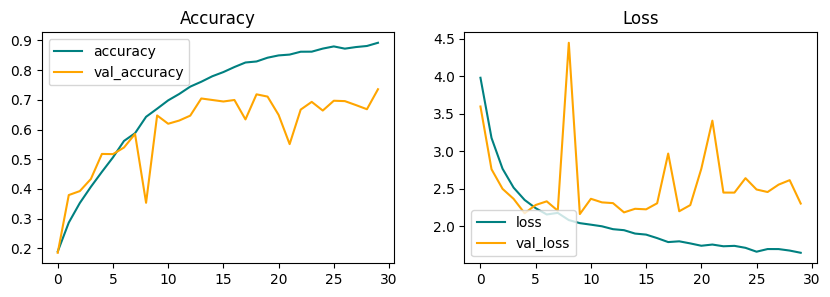

In [13]:
# Plot accuracy and loss over each epoch
_, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(history.history['accuracy'], color='teal', label='accuracy')
axes[0].plot(history.history['val_accuracy'], color='orange', label='val_accuracy')
axes[0].set_title('Accuracy')
axes[0].legend(loc="upper left")
axes[1].plot(history.history['loss'], color='teal', label='loss')
axes[1].plot(history.history['val_loss'], color='orange', label='val_loss')
axes[1].set_title('Loss')
axes[1].legend(loc="lower left")
plt.show()

99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


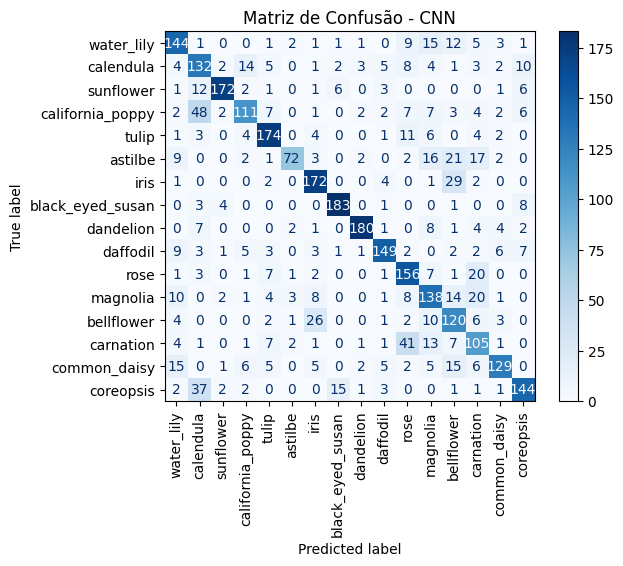

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict the entire test set
predictions = model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)

# Generate Confusion Matrix and get readable labels
cm = confusion_matrix(y_test, predicted_labels)
display_labels = [map_label_num_to_name[x] for x in y_test_classes]

# Generate Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
disp.plot(cmap='Blues', values_format='d')
plt.title("Matriz de Confusão - CNN")
plt.xticks(rotation=90)
plt.show()

99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
{'water_lily': 0, 'calendula': 1, 'sunflower': 2, 'california_poppy': 3, 'tulip': 4, 'astilbe': 5, 'iris': 6, 'black_eyed_susan': 7, 'dandelion': 8, 'daffodil': 9, 'rose': 10, 'magnolia': 11, 'bellflower': 12, 'carnation': 13, 'common_daisy': 14, 'coreopsis': 15}


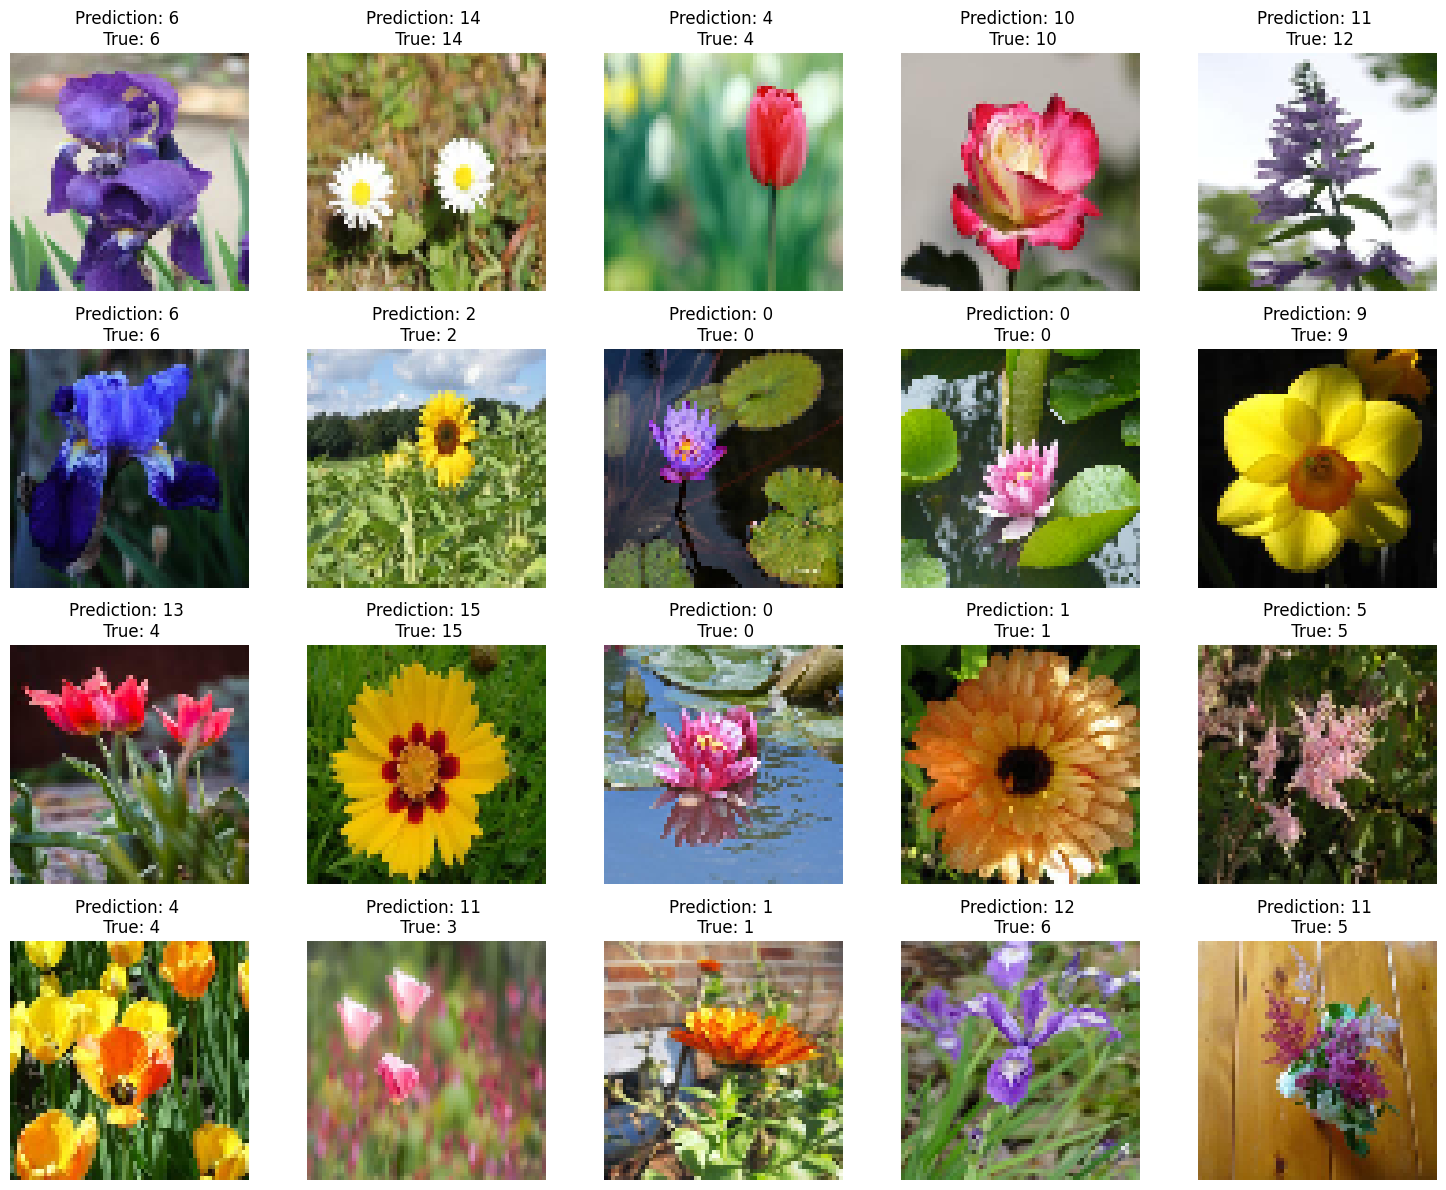

In [16]:
# Predict the entire test set
predictions = model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)

# Select 20 random indices from the test set
random_indices = np.random.choice(len(X_test), size=20, replace=False)

# Plot those instances with prediction and true labels
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
for i, index in enumerate(random_indices):
    row = i // 5
    col = i % 5
    image = X_test[index].reshape(64, 64, 3)  # Reshape to image format
    axes[row, col].imshow(image)
    axes[row, col].set_title(f"Prediction: {predicted_labels[index]} \n True: {y_test[index]}")
    axes[row, col].axis('off')
print(map_label_name_to_num)
plt.tight_layout()
plt.show()